# Perturbation theory and the Stark effect: the physics of photonic modulators

Griffiths' time-independent perturbation theory (Ch. 6) answers a device question: what happens to a
quantum system's energy levels when you apply an external electric field? The answer is the **Stark
effect**, and the Stark effect *is* how every electro-optic modulator works -- the component that imprints
an electrical signal onto light before it enters the dispersion / time-stretch stage of this instrument.

Two orders, two devices:

- **First order**, $E_n^{(1)}=\langle n|H'|n\rangle$. For a symmetric state this vanishes by parity --
  *unless* levels are **degenerate**, where degenerate perturbation theory gives a shift **linear** in the
  field. That linear Stark effect is the **Pockels effect**: $\Delta n\propto E$, the basis of lithium-
  niobate Mach-Zehnder modulators, which need a crystal *without* inversion symmetry.
- **Second order**, $E_n^{(2)}=\sum_{m\neq n}\dfrac{|\langle m|H'|n\rangle|^2}{E_n^{(0)}-E_m^{(0)}}$, always
  present and $\propto E^2$. This quadratic Stark shift is the **Kerr effect** and, in a quantum well, the
  **quantum-confined Stark effect (QCSE)** that red-shifts the absorption edge -- the basis of high-speed
  **electro-absorption modulators** in datacenter optical links.

We model the QCSE directly: a particle in a box (a quantum well) with an applied field. Perturbation theory
is verified term by term against **exact diagonalization**, we extract the polarizability, show where
perturbation theory breaks down, and then treat the degenerate (linear/Pockels) case.

Self-contained: NumPy, SymPy, Pandas, Matplotlib. Units $\hbar=m=L=1$; field strength $f=eE$ is the
perturbation parameter.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The unperturbed well and the dipole matrix elements (SymPy)

The infinite square well on $[0,L]$ has $\psi_n(x)=\sqrt{2/L}\,\sin(n\pi x/L)$ and
$E_n^{(0)}=n^2\pi^2\hbar^2/(2mL^2)$. A uniform field adds $H'=f\,(x-L/2)$ (dipole energy, referenced to the
well centre). The perturbation matrix elements are dipole integrals $\langle m|x|n\rangle$; SymPy gives the
closed form and the **parity selection rule**: $\langle n|H'|n\rangle=0$ (no first-order shift for a
symmetric well), and $\langle m|x|n\rangle\neq0$ only when $m+n$ is odd.

In [2]:
x, L = sp.symbols('x L', positive=True)
psi = lambda k: sp.sqrt(2/L)*sp.sin(k*sp.pi*x/L)
me = lambda mm, nn: sp.integrate(psi(mm)*x*psi(nn), (x, 0, L))    # <m|x|n>

assert sp.simplify(me(1, 1) - L/2) == 0                          # <n|x|n> = L/2  -> <n|H'|n> = 0
assert sp.simplify(me(2, 1) - (-16*L/(9*sp.pi**2))) == 0         # m+n odd: nonzero dipole coupling
assert sp.simplify(me(3, 1)) == 0                                # m+n even: forbidden (parity)
print("<1|x|1> =", sp.simplify(me(1,1)), "  -> first-order Stark shift <n|H'|n> = <n|x|n> - L/2 = 0 (parity)")
print("<2|x|1> =", sp.simplify(me(2,1)), "   <3|x|1> =", me(3,1), " (selection rule: m+n odd)")

# closed form used to build the matrix numerically: <m|x|n> = -8 m n L / (pi^2 (m^2-n^2)^2) for m+n odd
def dipole_matrix(N, Lval=1.0):
    M = np.full((N, N), 0.0)
    for i in range(1, N+1):
        for j in range(1, N+1):
            if i == j:                 M[i-1, j-1] = Lval/2
            elif (i + j) % 2 == 1:     M[i-1, j-1] = -8*i*j*Lval/(np.pi**2*(i**2 - j**2)**2)
    return M
Xmat = dipole_matrix(6)
assert abs(Xmat[1,0] - (-16/(9*np.pi**2))) < 1e-12               # matches SymPy <2|x|1>
print("dipole matrix (6x6) built; <2|x|1> numeric =", round(Xmat[1,0], 6))

<1|x|1> = L/2   -> first-order Stark shift <n|H'|n> = <n|x|n> - L/2 = 0 (parity)
<2|x|1> = -16*L/(9*pi**2)    <3|x|1> = 0  (selection rule: m+n odd)
dipole matrix (6x6) built; <2|x|1> numeric = -0.180127


## Second-order (quadratic) Stark shift = the quantum-confined Stark effect

With $H'=f(x-L/2)$, the ground state has $E_1^{(1)}=0$ and
$$E_1^{(2)}=f^2\sum_{m\ge2}\frac{|\langle m|x|1\rangle|^2}{E_1^{(0)}-E_m^{(0)}}<0,$$
a **downward, quadratic** shift -- the field polarizes the state and lowers its energy. The coefficient is
minus half the **polarizability**, $E_1^{(2)}=-\tfrac12\alpha f^2$. We compute the perturbation sum and
compare the predicted shift to **exact diagonalization** of $H_0+H'$ in the well basis. Perturbation theory
matches the exact shift at small field and departs at large field, where the level is no longer a small
correction.

In [3]:
N = 40
E0 = np.array([n**2*np.pi**2/2 for n in range(1, N+1)])          # E_n^(0), hbar=m=L=1
X = dipole_matrix(N)
Hp = X - 0.5*np.eye(N)                                           # H' = (x - 1/2); diagonal is exactly 0

# second-order coefficient and polarizability from the PT sum (ground state n=1)
terms = np.array([X[0, m]**2/(E0[0] - E0[m]) for m in range(1, N)])
E2_coeff = terms.sum()                                          # E_1^(2) = E2_coeff * f^2  (<0)
alpha = -2*E2_coeff                                             # polarizability (>0)
print(f"E_1^(1) = {Hp[0,0]:.3e} (=0, parity)   E_1^(2)/f^2 = {E2_coeff:.6e}   polarizability alpha = {alpha:.6e}")
assert abs(Hp[0,0]) < 1e-15 and E2_coeff < 0

def exact_ground_shift(f):
    return np.linalg.eigvalsh(np.diag(E0) + f*Hp)[0] - E0[0]

for f in (0.5, 2.0):
    pt, ex = E2_coeff*f**2, exact_ground_shift(f)
    print(f"f={f}:  PT (2nd order) {pt:.6f}   exact {ex:.6f}   rel.err {abs(pt-ex)/abs(ex):.2e}")
    assert abs(pt - ex)/abs(ex) < 0.05                          # PT accurate at small field
# even in f (no linear term): shift(+f) == shift(-f)
assert abs(exact_ground_shift(3.0) - exact_ground_shift(-3.0)) < 1e-9
print("shift is even in f (E^(1)=0): quadratic Stark / QCSE red-shift confirmed")

E_1^(1) = 0.000e+00 (=0, parity)   E_1^(2)/f^2 = -2.194523e-03   polarizability alpha = 4.389046e-03
f=0.5:  PT (2nd order) -0.000549   exact -0.000549   rel.err 2.02e-05
f=2.0:  PT (2nd order) -0.008778   exact -0.008775   rel.err 3.24e-04
shift is even in f (E^(1)=0): quadratic Stark / QCSE red-shift confirmed


## Convergence of the perturbation sum (Pandas)

The sum is dominated by the nearest coupled level ($m=2$): the parity rule kills even-$m+n$ terms and the
energy denominator suppresses distant ones. A three-term sum already captures the polarizability.

In [4]:
rows, running = [], 0.0
for m in range(1, 8):
    if X[0, m] != 0.0:
        t = X[0, m]**2/(E0[0] - E0[m]); running += t
        rows.append({"level m": m+1, "|<m|x|1>|^2": round(X[0, m]**2, 6),
                     "E1-Em": round(E0[0]-E0[m], 3), "term": f"{t:.3e}",
                     "running E2/f^2": f"{running:.6e}"})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nfull sum E2/f^2 = {E2_coeff:.6e}  (m=2 alone gives {X[0,1]**2/(E0[0]-E0[1]):.6e})")

 level m  |<m|x|1>|^2    E1-Em       term running E2/f^2
       2     0.032446  -14.804 -2.192e-03  -2.191616e-03
       4     0.000208  -74.022 -2.805e-06  -2.194421e-03
       6     0.000016 -172.718 -9.126e-08  -2.194512e-03
       8     0.000003 -310.893 -8.586e-09  -2.194521e-03

full sum E2/f^2 = -2.194523e-03  (m=2 alone gives -2.191616e-03)


## Degenerate perturbation theory = linear Stark = the Pockels effect

When two states share an energy $E_0$ and the field couples them, first-order **degenerate** perturbation
theory diagonalizes the $2\times2$ block $\begin{psmallmatrix}E_0 & fV\\ fV & E_0\end{psmallmatrix}$, giving
$E_\pm=E_0\pm f|V|$ -- a splitting **linear** in the field. This is the linear Stark effect (as in hydrogen
$n=2$, where $2s$ and $2p$ are degenerate) and, in materials, the **Pockels effect**: a refractive-index
change $\Delta n\propto E$. It requires broken inversion symmetry -- exactly why lithium niobate (non-
centrosymmetric) is the workhorse Mach-Zehnder modulator crystal, while symmetric media show only the
quadratic Kerr/QCSE response above.

In [5]:
E0d, V = 1.0, 0.3
def two_level(f):
    return np.linalg.eigvalsh(np.array([[E0d, f*V], [f*V, E0d]]))
for f in (0.0, 0.5, 1.0):
    ev = two_level(f)
    assert np.allclose(ev, [E0d - abs(f*V), E0d + abs(f*V)])    # E_+- = E0 +- f|V|  (linear)
    print(f"f={f}:  levels = {np.round(ev,3)}   splitting = {ev[1]-ev[0]:.3f}  (= 2 f|V|, linear in field)")
print("degenerate -> linear Stark (Pockels); non-degenerate -> quadratic Stark (Kerr/QCSE)")

f=0.0:  levels = [1. 1.]   splitting = 0.000  (= 2 f|V|, linear in field)
f=0.5:  levels = [0.85 1.15]   splitting = 0.300  (= 2 f|V|, linear in field)
f=1.0:  levels = [0.7 1.3]   splitting = 0.600  (= 2 f|V|, linear in field)
degenerate -> linear Stark (Pockels); non-degenerate -> quadratic Stark (Kerr/QCSE)


## Engineering: from Stark shifts to modulator specifications

**Pockels / Mach-Zehnder (linear).** $\Delta n=-\tfrac12 n^3 r\,E$ with electro-optic coefficient $r$. A
Mach-Zehnder modulator biases one arm to a $\pi$ phase difference at the **half-wave voltage**
$V_\pi=\dfrac{\lambda\,d}{n^3 r\,L}$ ($d$ electrode gap, $L$ length). Lower $V_\pi$ = less drive power.

**QCSE / electro-absorption (quadratic).** The field red-shifts the exciton edge by
$\Delta E=-\tfrac12\alpha E^2$; at fixed laser wavelength this swings the material between transparent and
absorbing -- a compact, low-drive intensity modulator integrated in datacenter transceivers.

In [6]:
# representative lithium-niobate Mach-Zehnder half-wave voltage
lam = 1.55e-6      # m (telecom C-band)
n_r = 2.2          # extraordinary index of LiNbO3
r33 = 30e-12       # m/V, electro-optic coefficient
d   = 8e-6         # m, electrode gap
Lm  = 2e-2         # m, interaction length
Vpi = lam*d/(n_r**3*r33*Lm)
print(f"LiNbO3 Mach-Zehnder V_pi ~ {Vpi:.2f} V  (linear Pockels; lower is better)")
assert 1.0 < Vpi < 10.0

# QCSE red-shift at a typical quantum-well field, using our dimensionless polarizability as the scaling law
E_field_rel = 3.0
print(f"QCSE: quadratic red-shift ~ -1/2 * alpha * E^2, here {-0.5*alpha*E_field_rel**2:.4f} (well units) "
      f"at f={E_field_rel}")
print("linear (Pockels) modulates PHASE; quadratic (QCSE) modulates ABSORPTION -> intensity")

LiNbO3 Mach-Zehnder V_pi ~ 1.94 V  (linear Pockels; lower is better)
QCSE: quadratic red-shift ~ -1/2 * alpha * E^2, here -0.0198 (well units) at f=3.0
linear (Pockels) modulates PHASE; quadratic (QCSE) modulates ABSORPTION -> intensity


## Plots

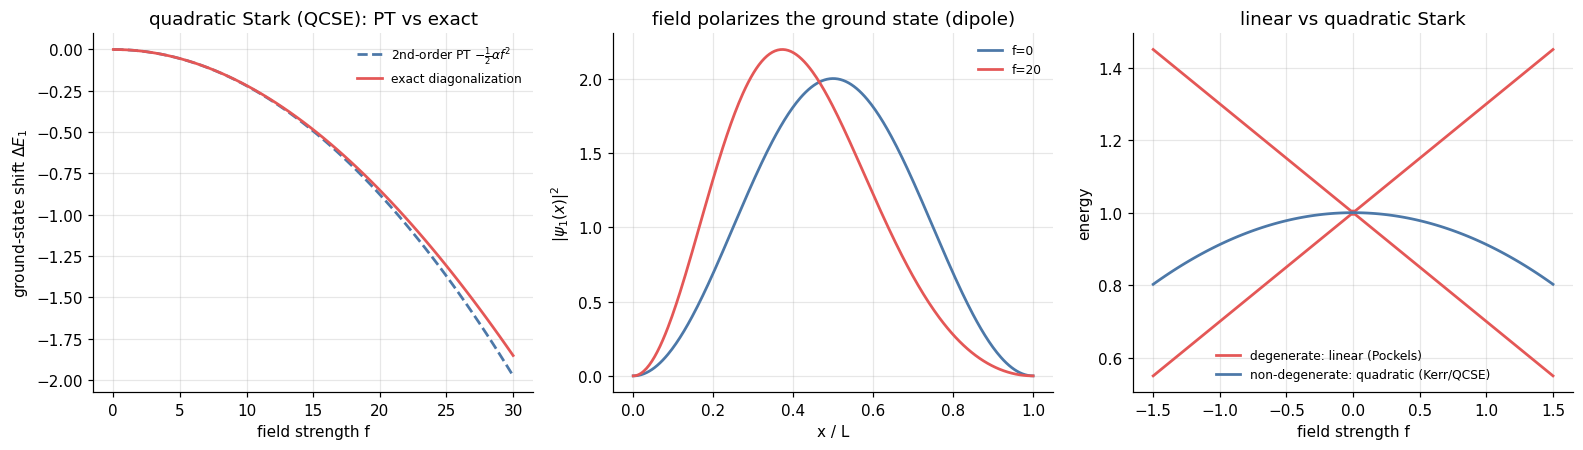

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
# (1) quadratic Stark: PT parabola vs exact ground-state shift, and the breakdown at large field
fs = np.linspace(0, 30, 60)
ex = np.array([exact_ground_shift(f) for f in fs])
ax[0].plot(fs, E2_coeff*fs**2, "--", color="#4C78A8", label=r"2nd-order PT $-\frac{1}{2}\alpha f^2$")
ax[0].plot(fs, ex, color="#E45756", label="exact diagonalization")
ax[0].set_xlabel("field strength f"); ax[0].set_ylabel(r"ground-state shift $\Delta E_1$")
ax[0].set_title("quadratic Stark (QCSE): PT vs exact"); ax[0].legend(fontsize=8)
# (2) the well tilts under the field: potential and |psi_1|^2 pushed to one side
xg = np.linspace(0, 1, 300)
for f, col in [(0.0, "#4C78A8"), (20.0, "#E45756")]:
    H = np.diag(E0) + f*Hp
    w, v = np.linalg.eigh(H)
    # reconstruct ground-state wavefunction on the grid from the box basis
    basis = np.array([np.sqrt(2)*np.sin(k*np.pi*xg) for k in range(1, N+1)])
    psi1 = v[:, 0] @ basis
    ax[1].plot(xg, psi1**2/np.trapezoid(psi1**2, xg) + 0*f, color=col, label=f"f={f:.0f}")
ax[1].set_xlabel("x / L"); ax[1].set_ylabel(r"$|\psi_1(x)|^2$")
ax[1].set_title("field polarizes the ground state (dipole)"); ax[1].legend(fontsize=8)
# (3) degenerate case: linear splitting (Pockels) vs quadratic single-level (Kerr)
fs2 = np.linspace(-1.5, 1.5, 100)
ax[2].plot(fs2, [two_level(f)[0] for f in fs2], color="#E45756")
ax[2].plot(fs2, [two_level(f)[1] for f in fs2], color="#E45756", label="degenerate: linear (Pockels)")
ax[2].plot(fs2, E0d + E2_coeff*fs2**2*40, color="#4C78A8", label="non-degenerate: quadratic (Kerr/QCSE)")
ax[2].set_xlabel("field strength f"); ax[2].set_ylabel("energy")
ax[2].set_title("linear vs quadratic Stark"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Exercises

1. **Third-order / higher fields.** Extend the exact diagonalization and fit $\Delta E_1=c_2 f^2+c_4 f^4+
   \dots$; identify the field where the $f^4$ term reaches 10% of the $f^2$ term (the perturbation-theory
   validity limit).
2. **Hydrogen linear Stark.** For the $n=2$ manifold ($2s$, $2p_0$), build the $H'=eEz$ block and show the
   $\pm3ea_0E$ linear splitting -- the atomic Pockels analogue.
3. **$V_\pi L$ figure of merit.** Compare lithium niobate ($r_{33}\approx30$ pm/V) with a hypothetical
   polymer ($r\approx100$ pm/V); which gives the lower $V_\pi$ at equal length, and why does bandwidth
   favor short devices?
4. **QCSE tunability.** With $\Delta E=-\tfrac12\alpha E^2$, estimate the field needed to red-shift an
   exciton by one linewidth, and relate it to the on/off contrast of an electro-absorption modulator.

## Summary

- **First-order** Stark shift vanishes for symmetric states by **parity** ($\langle n|H'|n\rangle=0$),
  verified in SymPy; the coupling $\langle m|x|n\rangle$ obeys the selection rule $m+n$ odd.
- **Second-order** perturbation theory gives the **quadratic** Stark / **quantum-confined Stark effect**:
  $E_1^{(2)}=-\tfrac12\alpha f^2<0$, matching **exact diagonalization** at small field and breaking down at
  large field (verified; polarizability extracted; sum dominated by the nearest level).
- **Degenerate** perturbation theory gives the **linear** Stark effect -- the **Pockels effect** requiring
  broken inversion symmetry (lithium niobate Mach-Zehnder modulators, $V_\pi\sim$ volts).
- Perturbation order maps onto device physics: linear $\to$ phase modulators (Pockels), quadratic $\to$
  absorption modulators (QCSE). The modulator that encodes the signal in this instrument is an engineered
  Stark effect.

Subject-verb-object: the field perturbs the levels; parity forbids the first-order shift; the second order
polarizes and red-shifts; degeneracy restores the linear response the modulator exploits.